# **Household Energy Pattern Segmentation and Consumption Prediction**
### IBM SkillsBuild Data Analytics with AI Internship Project

---

**Project Title:** Household Energy Pattern Segmentation and Consumption Prediction Using Machine Learning  
**Program:** IBM SkillsBuild Data Analytics with AI Internship  

---

## Problem Statement

Household energy consumption varies significantly based on time of day, season, appliance usage, and occupant behaviour. Without understanding these patterns, energy is often wasted. This project applies unsupervised machine learning (K-Means Clustering) to segment households into distinct energy-usage patterns, and supervised machine learning to predict future energy consumption — enabling smarter energy management decisions.

---

## Project Objectives

1. Load and explore a household energy consumption dataset.
2. Clean and preprocess the data for analysis.
3. Perform Exploratory Data Analysis (EDA) to understand distributions and trends.
4. Engineer meaningful features from time and consumption data.
5. Apply K-Means clustering to segment energy usage patterns.
6. Use the Elbow Method and Silhouette Score to select the optimal number of clusters.
7. Visualize clusters using Principal Component Analysis (PCA).
8. Build a supervised regression model to predict energy consumption.
9. Evaluate model performance using standard regression metrics.
10. Derive actionable energy-saving insights and recommendations.

---

## Workflow Overview

```
Data Loading → Quality Check → Cleaning → EDA → Feature Engineering
       → K-Means Clustering → Elbow + Silhouette → PCA Visualization
       → Prediction Model → Evaluation → Insights → Conclusion
```

---

> **Note:** All code cells are structured as templates. Run each cell after loading your dataset. No results are fabricated in this notebook.

---
## Section 0 — Import Libraries

We begin by importing all the Python libraries needed for this project.

| Library | Purpose |
|---|---|
| `pandas` | Data loading, manipulation, and cleaning |
| `numpy` | Numerical operations |
| `matplotlib` | Base plotting |
| `seaborn` | Statistical data visualization |
| `scikit-learn` | Machine learning models and metrics |

In [1]:
# ── Standard Libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Set a clean, consistent visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14

# ── Scikit-learn: Preprocessing ──────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ── Scikit-learn: Clustering ─────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ── Scikit-learn: Regression Models ─────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor

# ── Scikit-learn: Evaluation Metrics ────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


---
## Section 1 — Load Dataset

Place your dataset file (CSV format) in the same folder as this notebook.  
Update the `FILE_PATH` variable below with your actual filename.

**Expected columns** (adjust to your dataset):
- A datetime/date column
- One or more energy consumption columns (e.g., `Global_active_power`, `energy_kwh`)
- Optional: appliance-level, voltage, or sub-metering columns

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

matches = []

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "energydata_complete.csv" in files:
        matches.append(os.path.join(root, "energydata_complete.csv"))

print("Found files:")
for path in matches:
    print(path)

Found files:
/content/drive/MyDrive/Household_Energy_Project/energydata_complete.csv


In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
FILE_PATH = "/content/drive/MyDrive/Household_Energy_Project/energydata_complete.csv"

DATE_COLUMN = "date"
TIME_COLUMN = None
TARGET_COLUMN = "Appliances"

# Load the dataset
df = pd.read_csv(FILE_PATH, sep=',', low_memory=False)

# Preview the first few rows
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print('\nFirst 5 rows:')
df.head()


Dataset shape: 19735 rows × 29 columns

First 5 rows:


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


---
## Section 2 — Data Quality Check

Before cleaning, we inspect the dataset to understand:
- **Shape** — how many rows and columns exist
- **Data types** — numeric, categorical, datetime
- **Missing values** — percentage missing per column
- **Duplicates** — exact duplicate rows
- **Basic statistics** — min, max, mean, std of numeric columns

In [6]:
# ── Shape and Data Types ─────────────────────────────────────────────────────
print('=== Dataset Shape ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')

print('\n=== Column Data Types ===')
print(df.dtypes)

# ── Missing Values ────────────────────────────────────────────────────────────
print('\n=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# ── Duplicates ────────────────────────────────────────────────────────────────
dup_count = df.duplicated().sum()
print(f'\n=== Duplicate Rows: {dup_count} ===')

# ── Basic Statistics ──────────────────────────────────────────────────────────
print('\n=== Descriptive Statistics (Numeric Columns) ===')
df.describe()

=== Dataset Shape ===
Rows: 19,735  |  Columns: 29

=== Column Data Types ===
date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object

=== Missing Values ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

=== Duplicate Rows: 0 ===

=== Descriptive Statistics (Numeric Columns) ===


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [7]:
# ── Visualize Missing Values ──────────────────────────────────────────────────
missing_to_plot = missing_df[missing_df['Missing Count'] > 0]

if not missing_to_plot.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing_to_plot.index, missing_to_plot['Missing %'], color='salmon')
    ax.set_xlabel('Missing Values (%)')
    ax.set_title('Missing Value Percentage per Column')
    plt.tight_layout()
    plt.show()
else:
    print('✅ No missing values found in the dataset.')

✅ No missing values found in the dataset.


---
## Section 3 — Data Cleaning and Preprocessing

This section handles:
1. **Dropping duplicates** — remove exact duplicate rows
2. **Handling missing values** — fill or drop based on context
3. **Fixing data types** — parse dates, convert strings to numeric
4. **Removing outliers** — use the IQR method on the target column
5. **Creating a clean datetime index** — combine Date + Time columns if needed

In [8]:
# ── Data Cleaning and Preprocessing ──────────────────────────────────────────

# Step 1: Remove duplicate rows
before = len(df)

df = df.drop_duplicates().copy()

duplicates_removed = before - len(df)

print(f"Duplicates removed: {duplicates_removed}")


# ── Step 2: Handle Missing Values ────────────────────────────────────────────

# The original UCI dataset has no missing values, but this step
# makes the notebook robust if missing values are present.

# Remove rows where the prediction target is missing
df = df.dropna(subset=[TARGET_COLUMN]).copy()

# Identify numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Fill missing numeric values with their column median
if numeric_cols:
    df[numeric_cols] = df[numeric_cols].fillna(
        df[numeric_cols].median()
    )

print(f"Missing values after cleaning: {df.isnull().sum().sum()}")


# ── Step 3: Fix Data Types ────────────────────────────────────────────────────

# Convert the target column to numeric
df[TARGET_COLUMN] = pd.to_numeric(
    df[TARGET_COLUMN],
    errors="coerce"
)

# Remove rows where target conversion produced missing values
df = df.dropna(subset=[TARGET_COLUMN]).copy()


# ── Step 4: Parse Datetime ────────────────────────────────────────────────────

# The UCI dataset contains ONE combined datetime column named "date".
# There is no separate Time column.

df["Datetime"] = pd.to_datetime(
    df[DATE_COLUMN],
    errors="coerce"
)

# Remove rows with invalid datetime values
df = df.dropna(subset=["Datetime"]).copy()

# Sort observations chronologically
df = df.sort_values("Datetime").reset_index(drop=True)


# ── Step 5: Final Cleaning Summary ───────────────────────────────────────────

print("\n--- Cleaning Summary ---")
print(f"Clean dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print(f"Datetime range: {df['Datetime'].min()} to {df['Datetime'].max()}")

print("\nFirst 5 cleaned rows:")
display(df.head())

Duplicates removed: 0
Missing values after cleaning: 0

--- Cleaning Summary ---
Clean dataset shape: 19,735 rows × 30 columns
Remaining missing values: 0
Datetime range: 2016-01-11 17:00:00 to 2016-05-27 18:00:00

First 5 cleaned rows:


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,Datetime
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,2016-01-11 17:00:00
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,2016-01-11 17:10:00
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,2016-01-11 17:20:00
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,2016-01-11 17:30:00
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,2016-01-11 17:40:00


In [9]:
# ── Step 5: Remove Outliers using IQR ────────────────────────────────────────
Q1 = df[TARGET_COLUMN].quantile(0.25)
Q3 = df[TARGET_COLUMN].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before_outlier = len(df)
df = df[(df[TARGET_COLUMN] >= lower_bound) & (df[TARGET_COLUMN] <= upper_bound)]
print(f'Outliers removed: {before_outlier - len(df)}')
print(f'Dataset shape after outlier removal: {df.shape[0]:,} rows')

Outliers removed: 2138
Dataset shape after outlier removal: 17,597 rows


---
## Section 4 — Exploratory Data Analysis (EDA)

EDA helps us understand the dataset before modelling:
- **Distribution** of the target variable (energy consumption)
- **Correlation** between numeric features
- **Pairplot** to spot relationships between key variables
- **Boxplots** to observe spread and outliers visually

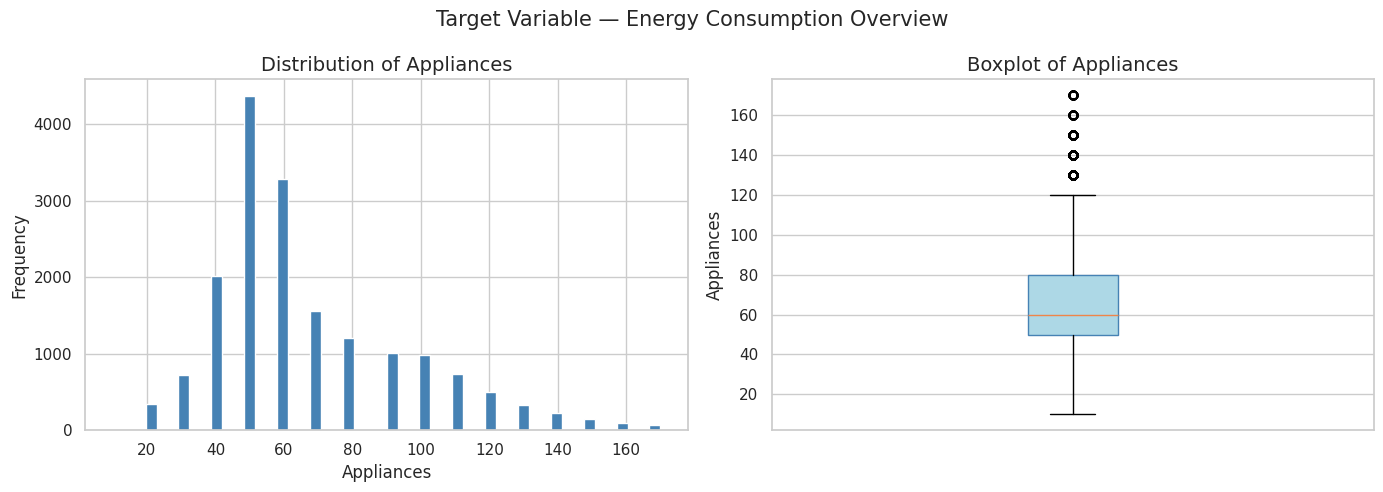

In [10]:
# ── Distribution of Target Variable ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET_COLUMN].dropna(), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title(f'Distribution of {TARGET_COLUMN}')
axes[0].set_xlabel(TARGET_COLUMN)
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df[TARGET_COLUMN].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'))
axes[1].set_title(f'Boxplot of {TARGET_COLUMN}')
axes[1].set_ylabel(TARGET_COLUMN)
axes[1].set_xticks([])

plt.suptitle('Target Variable — Energy Consumption Overview', fontsize=15)
plt.tight_layout()
plt.show()

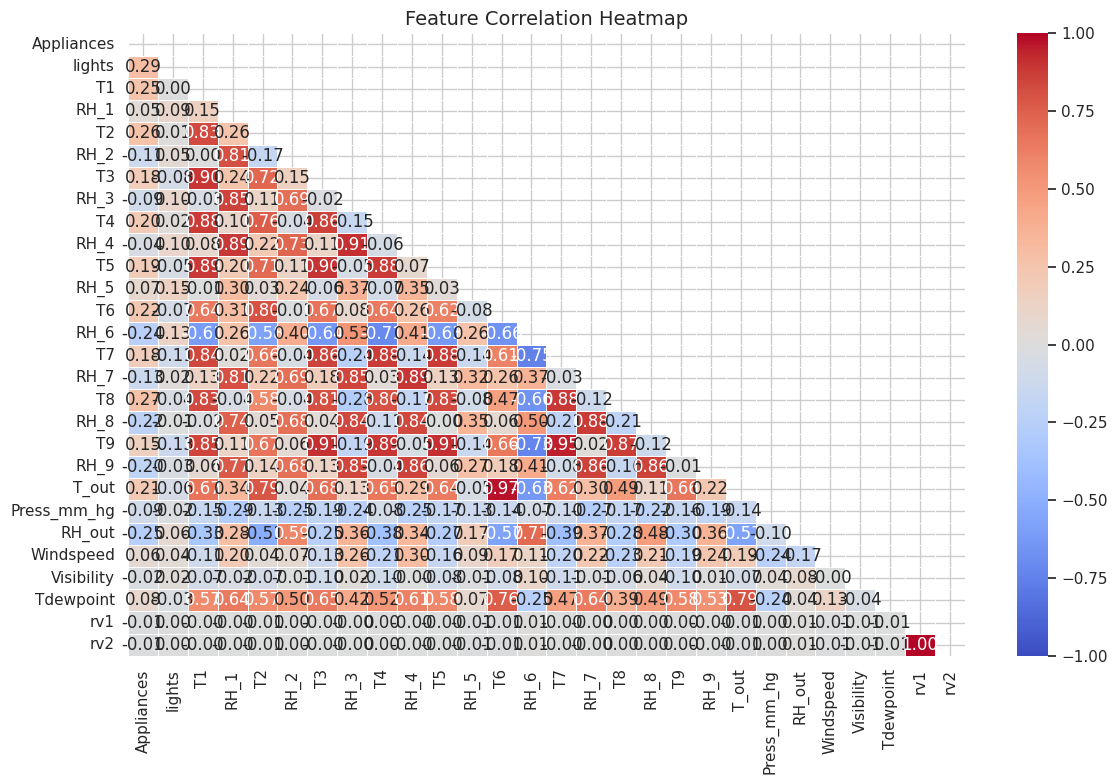

In [11]:
# ── Correlation Heatmap ───────────────────────────────────────────────────────
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

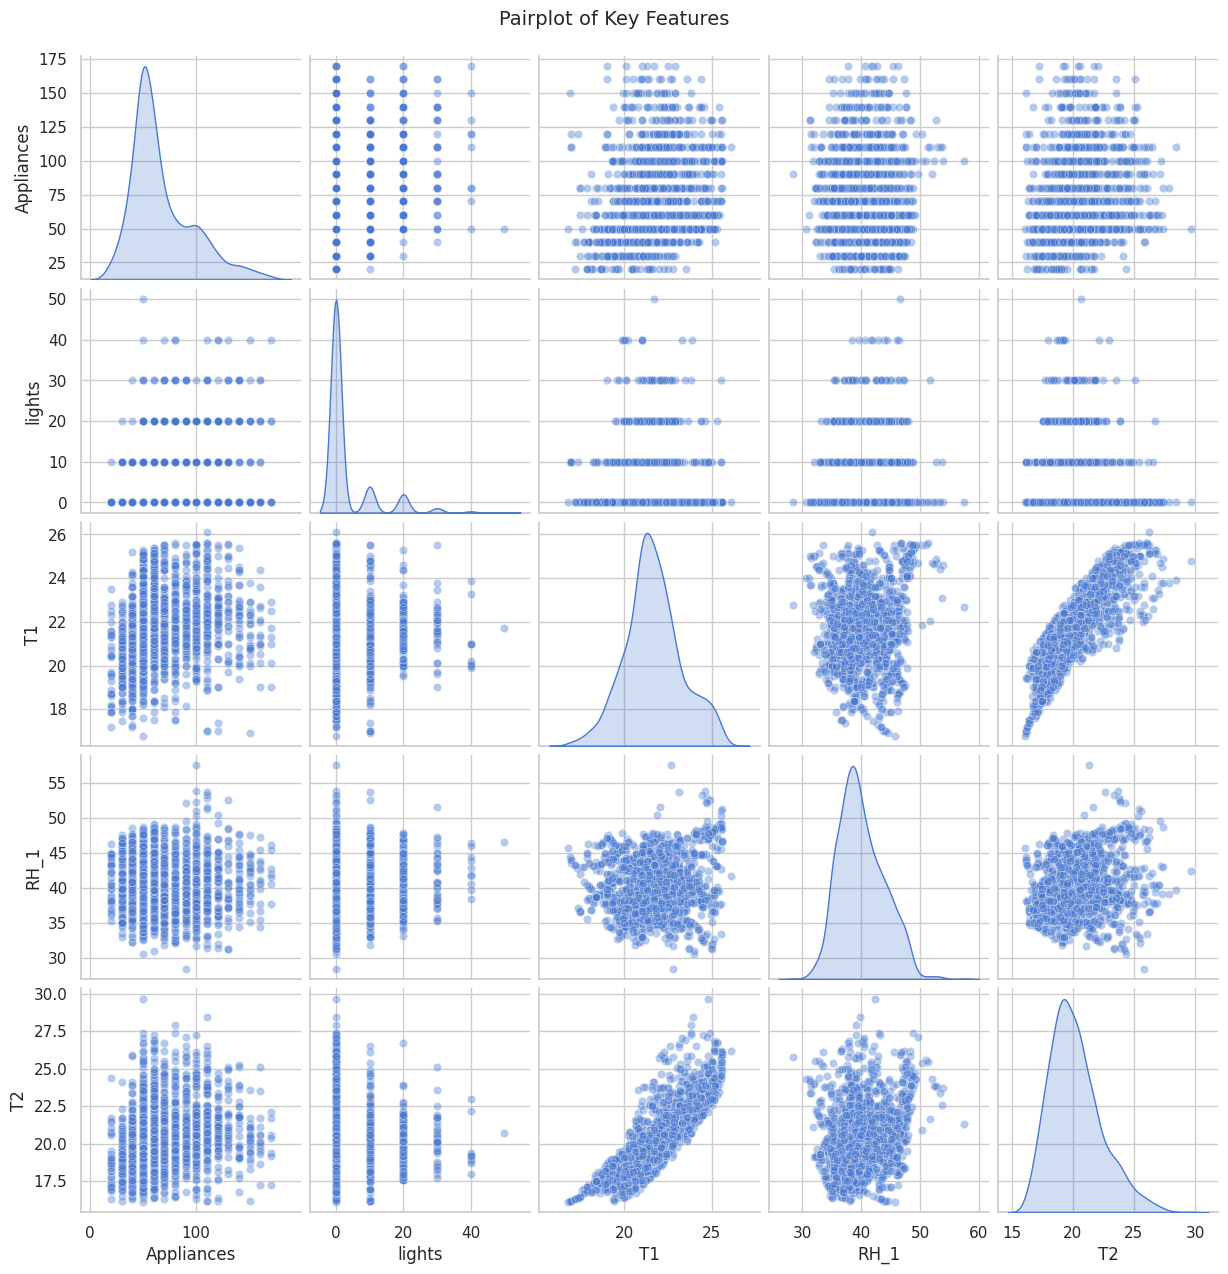

In [12]:
# ── Pairplot of Key Numeric Features ─────────────────────────────────────────
# Select a maximum of 5 columns for readability.
# Replace the list below with the column names most relevant to your dataset.
pairplot_cols = numeric_df.columns[:5].tolist()   # adjust as needed

sns.pairplot(df[pairplot_cols].dropna().sample(min(2000, len(df)), random_state=42),
             diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Key Features', y=1.02, fontsize=14)
plt.show()

---
## Section 5 — Time-Based and Energy-Consumption Feature Analysis

Energy usage often follows patterns over time:
- **Hourly** — morning and evening peaks
- **Daily** — weekday vs. weekend behaviour
- **Monthly/Seasonal** — winter heating, summer cooling

We extract these patterns from the datetime column and visualize them.

In [13]:
# ── Extract Temporal Features ─────────────────────────────────────────────────
df['Hour']       = df['Datetime'].dt.hour
df['DayOfWeek']  = df['Datetime'].dt.dayofweek   # 0=Monday … 6=Sunday
df['Month']      = df['Datetime'].dt.month
df['Year']       = df['Datetime'].dt.year
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)   # 1=Weekend, 0=Weekday
df['Quarter']    = df['Datetime'].dt.quarter

print('Temporal features added:', ['Hour','DayOfWeek','Month','Year','IsWeekend','Quarter'])

Temporal features added: ['Hour', 'DayOfWeek', 'Month', 'Year', 'IsWeekend', 'Quarter']


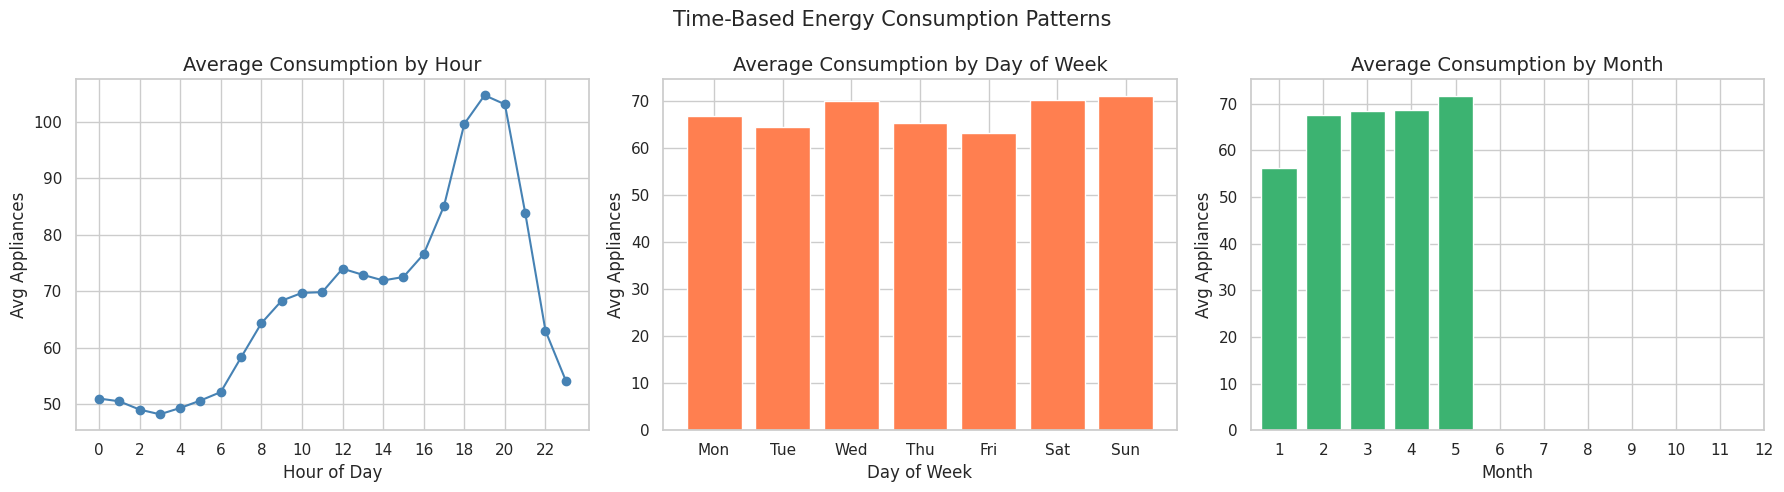

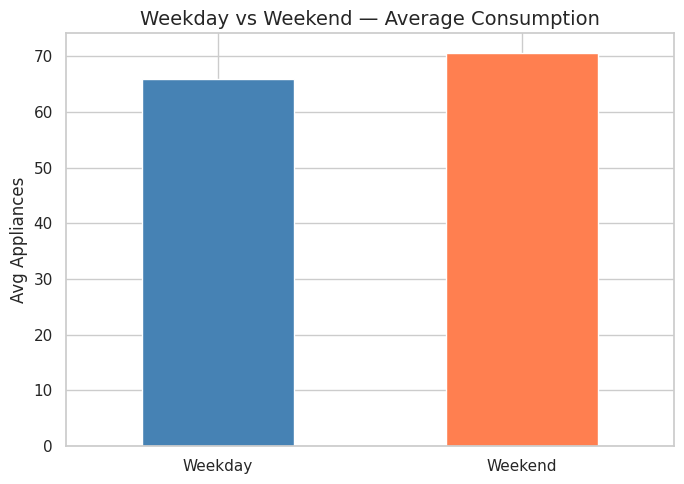

In [14]:
# ── Hourly Average Consumption ────────────────────────────────────────────────
hourly_avg = df.groupby('Hour')[TARGET_COLUMN].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Hourly
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='steelblue')
axes[0].set_title('Average Consumption by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel(f'Avg {TARGET_COLUMN}')
axes[0].set_xticks(range(0, 24, 2))

# (b) Day of Week
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily_avg = df.groupby('DayOfWeek')[TARGET_COLUMN].mean()
axes[1].bar(day_labels, daily_avg.values, color='coral')
axes[1].set_title('Average Consumption by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel(f'Avg {TARGET_COLUMN}')

# (c) Monthly
monthly_avg = df.groupby('Month')[TARGET_COLUMN].mean()
axes[2].bar(monthly_avg.index, monthly_avg.values, color='mediumseagreen')
axes[2].set_title('Average Consumption by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel(f'Avg {TARGET_COLUMN}')
axes[2].set_xticks(range(1, 13))

plt.suptitle('Time-Based Energy Consumption Patterns', fontsize=15)
plt.tight_layout()
plt.show()

# ── Weekday vs Weekend ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
df.groupby('IsWeekend')[TARGET_COLUMN].mean().plot(
    kind='bar', ax=ax, color=['steelblue','coral'], edgecolor='white'
)
ax.set_title('Weekday vs Weekend — Average Consumption')
ax.set_xlabel('')
ax.set_xticklabels(['Weekday', 'Weekend'], rotation=0)
ax.set_ylabel(f'Avg {TARGET_COLUMN}')
plt.tight_layout()
plt.show()

---
## Section 6 — Feature Engineering

Feature engineering transforms raw data into informative inputs for machine learning:

- **Rolling statistics** — 24-hour rolling mean and standard deviation capture local trends.
- **Lag features** — previous-period values allow the model to learn temporal dependencies.
- **Time-of-day category** — bucket hours into named periods (Night, Morning, Afternoon, Evening).
- **Season** — map months to seasons for richer temporal context.
- **Feature scaling** — standardize features before clustering (K-Means is distance-based).

In [15]:
# ── Rolling Statistics ────────────────────────────────────────────────────────
df['Rolling_Mean_24'] = df[TARGET_COLUMN].rolling(window=24, min_periods=1).mean()
df['Rolling_Std_24']  = df[TARGET_COLUMN].rolling(window=24, min_periods=1).std().fillna(0)

# ── Lag Features ──────────────────────────────────────────────────────────────
df['Lag_1']  = df[TARGET_COLUMN].shift(1)    # 1 period ago
df['Lag_24'] = df[TARGET_COLUMN].shift(24)   # same hour, 1 day ago

# ── Time-of-Day Category ──────────────────────────────────────────────────────
def time_of_day(hour):
    if 0 <= hour < 6:
        return 'Night'
    elif 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'

df['TimeOfDay'] = df['Hour'].apply(time_of_day)

# ── Season ─────────────────────────────────────────────────────────────────────
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

# ── Encode Categorical Features ───────────────────────────────────────────────
le = LabelEncoder()
df['TimeOfDay_Enc'] = le.fit_transform(df['TimeOfDay'])
df['Season_Enc']    = le.fit_transform(df['Season'])

# ── Drop rows with NaN from lag features ──────────────────────────────────────
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset shape after feature engineering: {df.shape}')
df[['Datetime', TARGET_COLUMN, 'Rolling_Mean_24', 'Lag_1', 'TimeOfDay', 'Season']].head(10)

Dataset shape after feature engineering: (17573, 44)


,Datetime,Appliances,Rolling_Mean_24,Lag_1,TimeOfDay,Season
0,2016-01-11 21:50:00,100,85.833333,100.0,Evening,Winter
1,2016-01-11 22:00:00,110,87.916667,100.0,Evening,Winter
2,2016-01-11 22:50:00,60,88.333333,110.0,Evening,Winter
3,2016-01-11 23:00:00,60,88.750000,60.0,Evening,Winter
4,2016-01-11 23:10:00,60,88.750000,60.0,Evening,Winter
5,2016-01-11 23:20:00,50,88.750000,60.0,Evening,Winter
6,2016-01-11 23:30:00,70,89.166667,50.0,Evening,Winter
7,2016-01-11 23:40:00,60,89.166667,70.0,Evening,Winter
8,2016-01-11 23:50:00,40,88.333333,60.0,Evening,Winter
9,2016-01-12 00:00:00,40,87.083333,40.0,Night,Winter


---
## Section 7 — K-Means Clustering for Energy Pattern Segmentation

**K-Means** is an unsupervised algorithm that partitions data into `k` clusters by minimizing within-cluster variance.

**Why K-Means for energy data?**
- Groups time observations with similar household energy-consumption characteristics.
- Each cluster represents a distinct energy-usage pattern (e.g., low, moderate, high users).
- Results can guide targeted energy-saving recommendations.

**Steps:**
1. Select clustering features.
2. Scale features (K-Means is sensitive to scale).
3. Fit K-Means with a chosen `k` (determined in Section 8).
4. Assign cluster labels back to the dataframe.

In [16]:
# ── Select Features for Clustering ───────────────────────────────────────────
# These features capture both consumption level and time behaviour.
# Adjust this list to match your dataset columns.
CLUSTER_FEATURES = [
    TARGET_COLUMN,
    'Rolling_Mean_24',
    'Rolling_Std_24',
    'Hour',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'TimeOfDay_Enc',
    'Season_Enc'
]

# Keep only available columns (in case some are absent in your dataset)
CLUSTER_FEATURES = [c for c in CLUSTER_FEATURES if c in df.columns]
print('Clustering features:', CLUSTER_FEATURES)

X_cluster = df[CLUSTER_FEATURES].copy()

# ── Scale Features ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
print(f'\nScaled feature matrix shape: {X_scaled.shape}')

Clustering features: ['Appliances', 'Rolling_Mean_24', 'Rolling_Std_24', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'TimeOfDay_Enc', 'Season_Enc']

Scaled feature matrix shape: (17573, 9)


---
## Section 8 — Elbow Method and Silhouette Score

Choosing the right number of clusters `k` is crucial:

- **Elbow Method:** Plot inertia (within-cluster sum of squares) vs. `k`. The 'elbow' point — where adding more clusters gives diminishing returns — suggests the best `k`.
- **Silhouette Score:** Measures how similar each point is to its own cluster vs. other clusters. Ranges from -1 to +1. Higher is better.

Together these two methods give a data-driven choice for `k`.

In [17]:
# ── Elbow Method and Silhouette Score ─────────────────────────────────────────

# Test a wider range of cluster counts
K_RANGE = range(2, 16)

inertia_values = []
silhouette_values = []

# Use a sample for faster computation
sample_size = min(10000, len(X_scaled))
X_sample = X_scaled[:sample_size]

for k in K_RANGE:

    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )

    labels = km.fit_predict(X_sample)

    inertia_values.append(km.inertia_)

    sil = silhouette_score(
        X_sample,
        labels,
        sample_size=min(3000, sample_size),
        random_state=42
    )

    silhouette_values.append(sil)

    print(
        f"k={k:2d} | "
        f"Inertia: {km.inertia_:>12.2f} | "
        f"Silhouette: {sil:.4f}"
    )

print("\n✅ Cluster evaluation completed.")

k= 2 | Inertia:     60519.36 | Silhouette: 0.2808
k= 3 | Inertia:     51495.64 | Silhouette: 0.2510
k= 4 | Inertia:     44010.30 | Silhouette: 0.2659
k= 5 | Inertia:     38169.93 | Silhouette: 0.2778
k= 6 | Inertia:     34216.39 | Silhouette: 0.2792
k= 7 | Inertia:     31033.12 | Silhouette: 0.2876
k= 8 | Inertia:     29116.19 | Silhouette: 0.2956
k= 9 | Inertia:     27388.92 | Silhouette: 0.3052
k=10 | Inertia:     25558.52 | Silhouette: 0.3130
k=11 | Inertia:     24105.57 | Silhouette: 0.3123
k=12 | Inertia:     22697.67 | Silhouette: 0.3123
k=13 | Inertia:     21943.98 | Silhouette: 0.2882
k=14 | Inertia:     21059.58 | Silhouette: 0.3154
k=15 | Inertia:     20382.63 | Silhouette: 0.2827

✅ Cluster evaluation completed.


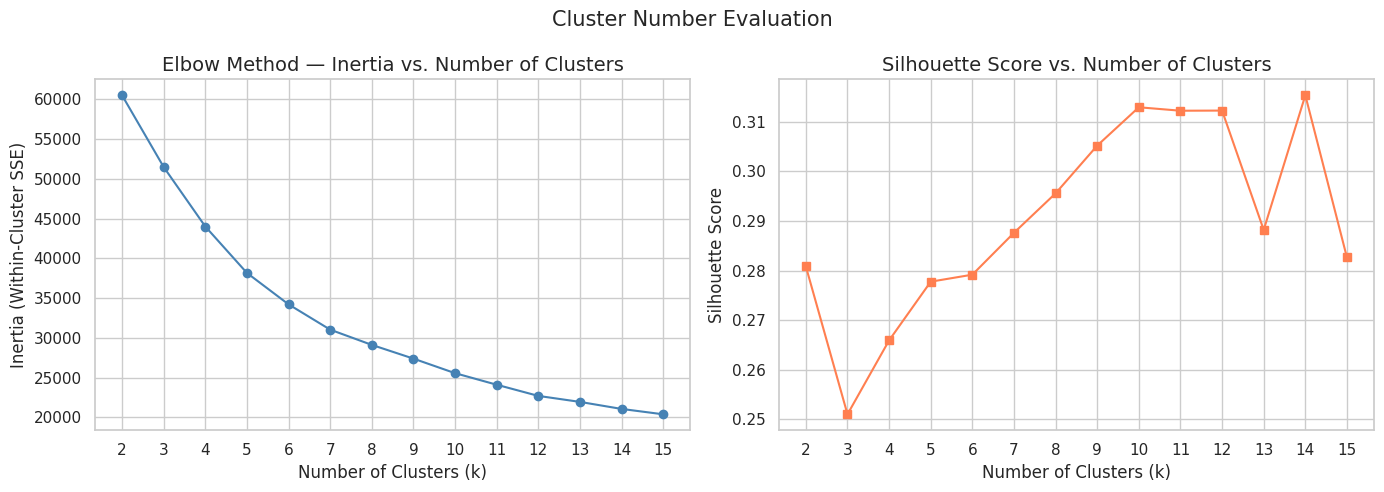


Review both plots before selecting the final number of clusters.
Use the Elbow Method together with the Silhouette Score.


In [18]:
# ── Plot Elbow Curve and Silhouette Scores ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(list(K_RANGE), inertia_values, marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Inertia vs. Number of Clusters')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].set_xticks(list(K_RANGE))
axes[0].grid(True)

# Silhouette
axes[1].plot(list(K_RANGE), silhouette_values, marker='s', color='coral')
axes[1].set_title('Silhouette Score vs. Number of Clusters')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_RANGE))
axes[1].grid(True)

plt.suptitle('Cluster Number Evaluation', fontsize=15)
plt.tight_layout()
plt.show()

print("\nReview both plots before selecting the final number of clusters.")
print("Use the Elbow Method together with the Silhouette Score.")

In [19]:
# ── Fit Final K-Means Model ───────────────────────────────────────────────────
OPTIMAL_K = 10    # <-- Set this after reviewing the plots above

kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f'K-Means fitted with k = {OPTIMAL_K}')
print('\nCluster distribution:')
print(df['Cluster'].value_counts().sort_index())

K-Means fitted with k = 10

Cluster distribution:
Cluster
0     886
1    4108
2     738
3    1488
4     875
5    2191
6    1655
7    2686
8    1461
9    1485
Name: count, dtype: int64


---
## Section 9 — Cluster Visualization using PCA

K-Means operates in a high-dimensional feature space — we cannot directly plot it.  
**Principal Component Analysis (PCA)** reduces the feature dimensions to 2D or 3D while retaining maximum variance, allowing us to visually inspect cluster separation.

- A well-separated scatter plot confirms that K-Means found meaningful clusters.
- Overlapping clusters suggest patterns that are harder to distinguish.

In [20]:
# ── PCA: Reduce to 2 Components ───────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_ * 100
print(f'PCA Component 1: {explained[0]:.2f}% variance explained')
print(f'PCA Component 2: {explained[1]:.2f}% variance explained')
print(f'Total variance retained: {sum(explained):.2f}%')

# Add PCA results to the dataframe
df['PCA_1'] = X_pca[:, 0]
df['PCA_2'] = X_pca[:, 1]

PCA Component 1: 33.99% variance explained
PCA Component 2: 20.92% variance explained
Total variance retained: 54.91%


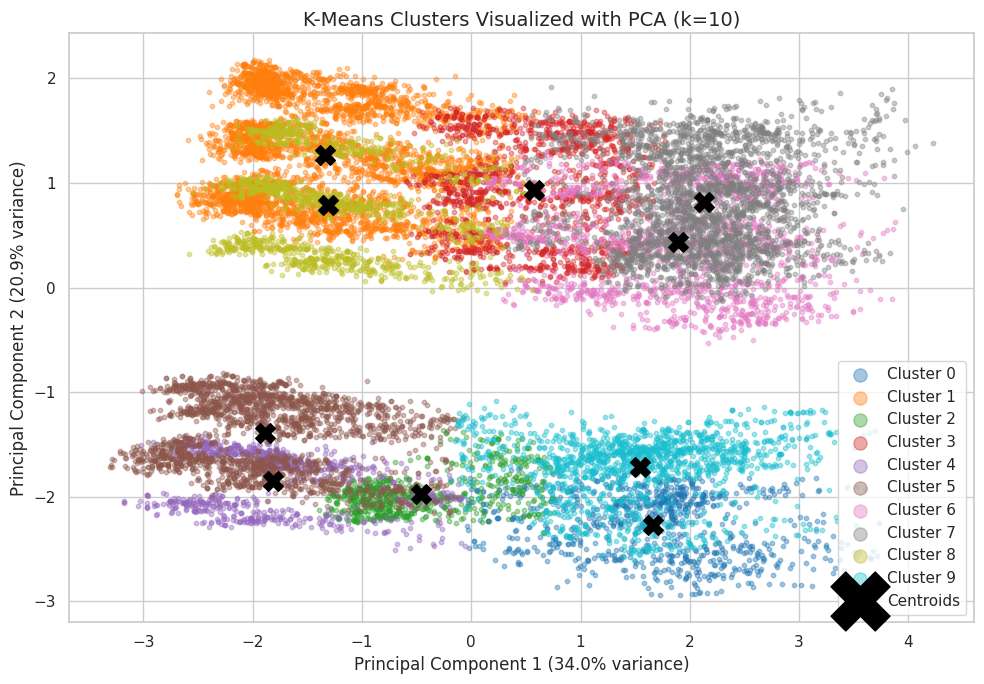

In [21]:
# ── Scatter Plot: PCA Cluster Visualization ───────────────────────────────────
palette = sns.color_palette('tab10', OPTIMAL_K)

plt.figure(figsize=(10, 7))
for cluster_id in range(OPTIMAL_K):
    mask = df['Cluster'] == cluster_id
    plt.scatter(
        df.loc[mask, 'PCA_1'],
        df.loc[mask, 'PCA_2'],
        label=f'Cluster {cluster_id}',
        alpha=0.4, s=10,
        color=palette[cluster_id]
    )

# Plot cluster centroids transformed through PCA
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, c='black', label='Centroids', zorder=5)

plt.title(f'K-Means Clusters Visualized with PCA (k={OPTIMAL_K})', fontsize=14)
plt.xlabel(f'Principal Component 1 ({explained[0]:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({explained[1]:.1f}% variance)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

In [22]:
# ── Cluster Profile — Mean of Each Feature per Cluster ───────────────────────
cluster_profile = df.groupby('Cluster')[CLUSTER_FEATURES].mean().round(3)
print('=== Cluster Profiles (Mean Values) ===')
cluster_profile

=== Cluster Profiles (Mean Values) ===


,Appliances,Rolling_Mean_24,Rolling_Std_24,Hour,DayOfWeek,Month,IsWeekend,TimeOfDay_Enc,Season_Enc
Cluster,,,,,,,,,
0,88.849,85.268,24.472,17.008,5.501,1.576,1.0,0.661,1.0
1,55.630,56.454,13.323,5.044,1.982,3.949,0.0,2.559,0.0
2,44.770,46.463,13.503,16.554,2.062,1.196,0.0,0.333,1.0
3,62.345,61.095,15.016,15.013,2.098,4.059,0.0,0.112,0.0
4,46.183,48.799,13.196,5.176,5.495,1.627,1.0,2.511,1.0
5,48.343,51.297,14.385,4.940,1.997,1.574,0.0,2.567,1.0
6,88.526,87.075,20.909,16.958,5.532,3.976,1.0,0.677,0.0
7,91.657,91.431,26.203,18.517,1.990,3.924,0.0,0.875,0.0
8,53.860,54.691,12.012,4.857,5.504,3.923,1.0,2.550,0.0


In [23]:
# ── Readable Cluster Interpretation ───────────────────────────────────────────

cluster_interpretation = []

for cluster_id, group in df.groupby('Cluster'):

    # Average consumption
    avg_consumption = group[TARGET_COLUMN].mean()

    # Dominant hour
    peak_hour = group.groupby('Hour')[TARGET_COLUMN].mean().idxmax()

    # Dominant time of day
    dominant_time = group['TimeOfDay'].mode().iloc[0]

    # Dominant day type
    dominant_day_type = (
        'Weekend'
        if group['IsWeekend'].mean() >= 0.5
        else 'Weekday'
    )

    # Dominant season
    dominant_season = group['Season'].mode().iloc[0]

    # Number of observations
    count = len(group)

    cluster_interpretation.append({
        'Cluster': cluster_id,
        'Observations': count,
        'Average Consumption (Wh)': round(avg_consumption, 2),
        'Peak Hour': peak_hour,
        'Dominant Time of Day': dominant_time,
        'Dominant Day Type': dominant_day_type,
        'Dominant Season': dominant_season
    })

cluster_interpretation_df = pd.DataFrame(
    cluster_interpretation
).sort_values('Cluster')

print("=== Readable Cluster Interpretation ===")
display(cluster_interpretation_df)

=== Readable Cluster Interpretation ===


,Cluster,Observations,Average Consumption (Wh),Peak Hour,Dominant Time of Day,Dominant Day Type,Dominant Season
0,0,886,88.85,7,Evening,Weekend,Winter
1,1,4108,55.63,7,Night,Weekday,Spring
2,2,738,44.77,16,Afternoon,Weekday,Winter
3,3,1488,62.35,18,Afternoon,Weekday,Spring
4,4,875,46.18,20,Night,Weekend,Winter
5,5,2191,48.34,9,Night,Weekday,Winter
6,6,1655,88.53,8,Evening,Weekend,Spring
7,7,2686,91.66,5,Evening,Weekday,Spring
8,8,1461,53.86,8,Night,Weekend,Spring
9,9,1485,87.47,6,Evening,Weekday,Winter


In [24]:
# ── Assign Descriptive Cluster Labels ─────────────────────────────────────────

def consumption_level(value):
    if value < 55:
        return 'Lower'
    elif value < 75:
        return 'Moderate'
    else:
        return 'Higher'


cluster_interpretation_df['Consumption Level'] = (
    cluster_interpretation_df['Average Consumption (Wh)']
    .apply(consumption_level)
)

cluster_interpretation_df['Pattern Label'] = (
    cluster_interpretation_df['Consumption Level']
    + ' ' +
    cluster_interpretation_df['Dominant Time of Day']
    + ' Pattern'
)

print("=== Final Cluster Pattern Labels ===")
display(cluster_interpretation_df)

=== Final Cluster Pattern Labels ===


,Cluster,Observations,Average Consumption (Wh),Peak Hour,Dominant Time of Day,Dominant Day Type,Dominant Season,Consumption Level,Pattern Label
0,0,886,88.85,7,Evening,Weekend,Winter,Higher,Higher Evening Pattern
1,1,4108,55.63,7,Night,Weekday,Spring,Moderate,Moderate Night Pattern
2,2,738,44.77,16,Afternoon,Weekday,Winter,Lower,Lower Afternoon Pattern
3,3,1488,62.35,18,Afternoon,Weekday,Spring,Moderate,Moderate Afternoon Pattern
4,4,875,46.18,20,Night,Weekend,Winter,Lower,Lower Night Pattern
5,5,2191,48.34,9,Night,Weekday,Winter,Lower,Lower Night Pattern
6,6,1655,88.53,8,Evening,Weekend,Spring,Higher,Higher Evening Pattern
7,7,2686,91.66,5,Evening,Weekday,Spring,Higher,Higher Evening Pattern
8,8,1461,53.86,8,Night,Weekend,Spring,Lower,Lower Night Pattern
9,9,1485,87.47,6,Evening,Weekday,Winter,Higher,Higher Evening Pattern


In [25]:
# ── Detailed Cluster Labels for Final Report ──────────────────────────────────

def create_cluster_label(row):
    return (
        f"{row['Consumption Level']} "
        f"{row['Dominant Time of Day']} "
        f"{row['Dominant Day Type']} "
        f"{row['Dominant Season']} Pattern"
    )

cluster_interpretation_df['Detailed Pattern'] = (
    cluster_interpretation_df.apply(create_cluster_label, axis=1)
)

final_cluster_table = cluster_interpretation_df[
    [
        'Cluster',
        'Observations',
        'Average Consumption (Wh)',
        'Peak Hour',
        'Dominant Time of Day',
        'Dominant Day Type',
        'Dominant Season',
        'Detailed Pattern'
    ]
].copy()

print("=== Final Cluster Interpretation Table ===")
display(final_cluster_table)

=== Final Cluster Interpretation Table ===


,Cluster,Observations,Average Consumption (Wh),Peak Hour,Dominant Time of Day,Dominant Day Type,Dominant Season,Detailed Pattern
0,0,886,88.85,7,Evening,Weekend,Winter,Higher Evening Weekend Winter Pattern
1,1,4108,55.63,7,Night,Weekday,Spring,Moderate Night Weekday Spring Pattern
2,2,738,44.77,16,Afternoon,Weekday,Winter,Lower Afternoon Weekday Winter Pattern
3,3,1488,62.35,18,Afternoon,Weekday,Spring,Moderate Afternoon Weekday Spring Pattern
4,4,875,46.18,20,Night,Weekend,Winter,Lower Night Weekend Winter Pattern
5,5,2191,48.34,9,Night,Weekday,Winter,Lower Night Weekday Winter Pattern
6,6,1655,88.53,8,Evening,Weekend,Spring,Higher Evening Weekend Spring Pattern
7,7,2686,91.66,5,Evening,Weekday,Spring,Higher Evening Weekday Spring Pattern
8,8,1461,53.86,8,Night,Weekend,Spring,Lower Night Weekend Spring Pattern
9,9,1485,87.47,6,Evening,Weekday,Winter,Higher Evening Weekday Winter Pattern


In [26]:
# ── Identify High and Low Consumption Clusters ────────────────────────────────

highest_cluster = final_cluster_table.loc[
    final_cluster_table['Average Consumption (Wh)'].idxmax()
]

lowest_cluster = final_cluster_table.loc[
    final_cluster_table['Average Consumption (Wh)'].idxmin()
]

print("=== Highest Average Consumption Cluster ===")
display(highest_cluster.to_frame().T)

print("\n=== Lowest Average Consumption Cluster ===")
display(lowest_cluster.to_frame().T)

=== Highest Average Consumption Cluster ===


,Cluster,Observations,Average Consumption (Wh),Peak Hour,Dominant Time of Day,Dominant Day Type,Dominant Season,Detailed Pattern
7,7,2686,91.66,5,Evening,Weekday,Spring,Higher Evening Weekday Spring Pattern



=== Lowest Average Consumption Cluster ===


,Cluster,Observations,Average Consumption (Wh),Peak Hour,Dominant Time of Day,Dominant Day Type,Dominant Season,Detailed Pattern
2,2,738,44.77,16,Afternoon,Weekday,Winter,Lower Afternoon Weekday Winter Pattern


---
## Section 10 — Supervised Machine Learning: Energy Consumption Prediction

Now we build a **regression model** to predict the numeric energy consumption value.

**Why supervised learning after clustering?**
- Clustering identified *patterns* (who uses energy in what way).
- The prediction model forecasts *future consumption* given time and usage features.
- The cluster label is added as an additional feature — leveraging unsupervised insights in a supervised model.

**Models compared:**
| Model | Type | Key Strength |
|---|---|---|
| Linear Regression | Parametric | Simple, interpretable baseline |
| Decision Tree | Non-parametric | Captures non-linear splits |
| Random Forest | Ensemble | Robust, low variance |
| Gradient Boosting | Ensemble | High accuracy |

**Train/Test Split:** 80% training, 20% testing.

In [27]:
# ── Define Prediction Features and Target ─────────────────────────────────────

# We predict the NEXT 10-minute Appliances consumption value.
# Only information available at the current time is used as input.

PRED_FEATURES = [
    # Time-based features
    'Hour',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'Quarter',
    'TimeOfDay_Enc',
    'Season_Enc',

    # Current environmental / usage measurements
    'lights',
    'T1', 'RH_1',
    'T2', 'RH_2',
    'T3', 'RH_3',
    'T4', 'RH_4',
    'T5', 'RH_5',
    'T6', 'RH_6',
    'T7', 'RH_7',
    'T8', 'RH_8',
    'T9', 'RH_9',
    'T_out',
    'Press_mm_hg',
    'RH_out',
    'Windspeed',
    'Visibility',
    'Tdewpoint',

    # Previous consumption values
    'Lag_1',
    'Lag_24'
]

# Keep only columns that actually exist
PRED_FEATURES = [c for c in PRED_FEATURES if c in df.columns]

print("Prediction features:")
print(PRED_FEATURES)

# Create next 10-minute consumption target
df['Target_Next_10min'] = df[TARGET_COLUMN].shift(-1)

# Remove final row because it has no next observation
prediction_df = df.dropna(
    subset=PRED_FEATURES + ['Target_Next_10min']
).copy()

X = prediction_df[PRED_FEATURES]
y = prediction_df['Target_Next_10min']

print(f"\nPrediction dataset shape: {prediction_df.shape}")
print(f"Number of features: {len(PRED_FEATURES)}")

Prediction features:
['Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Quarter', 'TimeOfDay_Enc', 'Season_Enc', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'Lag_1', 'Lag_24']

Prediction dataset shape: (17572, 48)
Number of features: 34


In [28]:
# ── Chronological Train / Test Split ──────────────────────────────────────────

# For time-series data, keep earlier observations for training
# and later observations for testing.

split_index = int(len(prediction_df) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")

print("\nTraining period:")
print(prediction_df['Datetime'].iloc[0], "to",
      prediction_df['Datetime'].iloc[split_index - 1])

print("\nTesting period:")
print(prediction_df['Datetime'].iloc[split_index], "to",
      prediction_df['Datetime'].iloc[-1])

Training samples : 14,057
Testing samples  : 3,515

Training period:
2016-01-11 21:50:00 to 2016-05-01 01:10:00

Testing period:
2016-05-01 01:20:00 to 2016-05-27 17:20:00


In [29]:
# ── Retrain Models Using the Corrected Prediction Features ────────────────────

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

    print(
        f'{name:<25} '
        f'MAE={mae:.4f}  '
        f'RMSE={rmse:.4f}  '
        f'R²={r2:.4f}'
    )

print("\n✅ Models retrained using the corrected feature set.")

Linear Regression         MAE=12.1841  RMSE=17.8987  R²=0.5473
Decision Tree             MAE=16.6273  RMSE=25.4224  R²=0.0868
Random Forest             MAE=16.2539  RMSE=21.6255  R²=0.3392
Gradient Boosting         MAE=11.4610  RMSE=16.9651  R²=0.5933

✅ Models retrained using the corrected feature set.


In [30]:
# ── Verify the Newly Trained Random Forest ────────────────────────────────────

rf_predictions = models['Random Forest'].predict(X_test)

print("First 5 actual values:")
print(y_test.head().to_list())

print("\nFirst 5 Random Forest predictions:")
print(rf_predictions[:5])

print("\nRandom Forest features used during training:")
print(models['Random Forest'].feature_names_in_.tolist())

print("\nCurrent prediction features:")
print(PRED_FEATURES)

print("\nNumber of features used by model:",
      len(models['Random Forest'].feature_names_in_))

print("\nNumber of current prediction features:",
      len(PRED_FEATURES))

print("\n✅ Model feature check completed.")

First 5 actual values:
[50.0, 60.0, 50.0, 40.0, 50.0]

First 5 Random Forest predictions:
[45.6 57.8 46.5 56.6 48. ]

Random Forest features used during training:
['Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Quarter', 'TimeOfDay_Enc', 'Season_Enc', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'Lag_1', 'Lag_24']

Current prediction features:
['Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Quarter', 'TimeOfDay_Enc', 'Season_Enc', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'Lag_1', 'Lag_24']

Number of features used by model: 34

Number of current prediction features: 34

✅ Model feature check completed.


In [31]:
# ── Verify Prediction Setup ───────────────────────────────────────────────────

print("Prediction target:")
print("Target_Next_10min")

print("\nPrediction features:")
print(PRED_FEATURES)

print("\nLeakage check:")
leakage_features = [
    'Appliances',
    'Rolling_Mean_24',
    'Rolling_Std_24',
    'Cluster'
]

for feature in leakage_features:
    if feature in PRED_FEATURES:
        print(f"⚠️ {feature} is being used")
    else:
        print(f"✅ {feature} is NOT being used")

print("\nChronological split confirmed:")
print(f"Training ends: {prediction_df['Datetime'].iloc[split_index - 1]}")
print(f"Testing starts: {prediction_df['Datetime'].iloc[split_index]}")

Prediction target:
Target_Next_10min

Prediction features:
['Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Quarter', 'TimeOfDay_Enc', 'Season_Enc', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'Lag_1', 'Lag_24']

Leakage check:
✅ Appliances is NOT being used
✅ Rolling_Mean_24 is NOT being used
✅ Rolling_Std_24 is NOT being used
✅ Cluster is NOT being used

Chronological split confirmed:
Training ends: 2016-05-01 01:10:00
Testing starts: 2016-05-01 01:20:00


In [32]:
# ── Prediction Sanity Check ───────────────────────────────────────────────────

print("Current target statistics:")
print(y.describe())

print("\nFirst 5 actual target values:")
print(y_test.head().to_list())

print("\nFirst 5 Random Forest predictions:")
rf_predictions = models['Random Forest'].predict(X_test)
print(rf_predictions[:5])

print("\nPrediction target is:")
print(prediction_df['Target_Next_10min'].name)

print("\n✅ Sanity check completed.")

Current target statistics:
count    17572.000000
mean        67.184726
std         28.477010
min         10.000000
25%         50.000000
50%         60.000000
75%         80.000000
max        170.000000
Name: Target_Next_10min, dtype: float64

First 5 actual target values:
[50.0, 60.0, 50.0, 40.0, 50.0]

First 5 Random Forest predictions:
[45.6 57.8 46.5 56.6 48. ]

Prediction target is:
Target_Next_10min

✅ Sanity check completed.


---
## Section 11 — Model Evaluation

We evaluate regression performance using:

| Metric | Formula | Meaning |
|---|---|---|
| **MAE** | Mean(\|y − ŷ\|) | Average absolute error; easy to interpret |
| **RMSE** | √Mean((y − ŷ)²) | Penalizes large errors more; same units as target |
| **R²** | 1 − SS_res/SS_tot | Proportion of variance explained; 1.0 = perfect |

We also:
- Compare models in a summary table.
- Plot **Actual vs Predicted** values for the best model.
- Plot **Feature Importance** for the Random Forest model.

In [33]:
# ── Results Summary Table ─────────────────────────────────────────────────────
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('R2', ascending=False)
print('=== Model Comparison ===')
results_df

=== Model Comparison ===


,MAE,MSE,RMSE,R2
Gradient Boosting,11.4610,287.8160,16.9651,0.5933
Linear Regression,12.1841,320.3649,17.8987,0.5473
Random Forest,16.2539,467.6620,21.6255,0.3392
Decision Tree,16.6273,646.2994,25.4224,0.0868


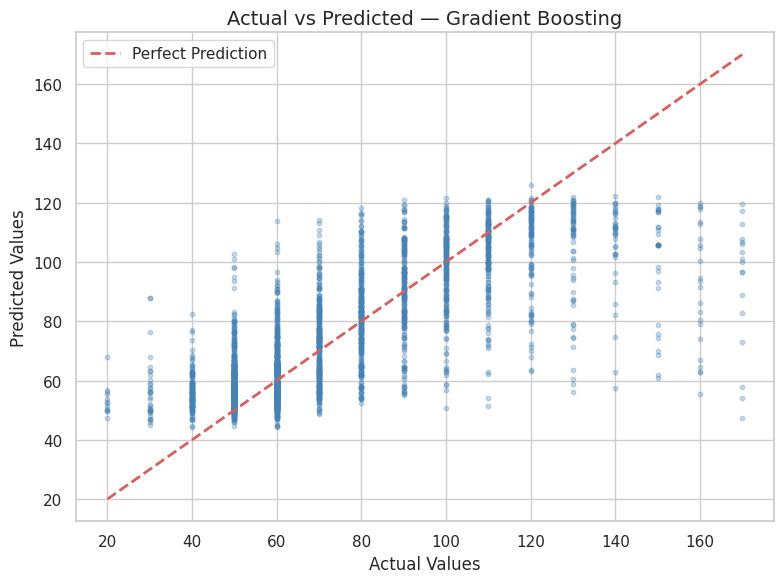

In [34]:
# ── Best Model: Actual vs Predicted Plot ──────────────────────────────────────
best_model_name = results_df.index[0]
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=10, color='steelblue')
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.tight_layout()
plt.show()

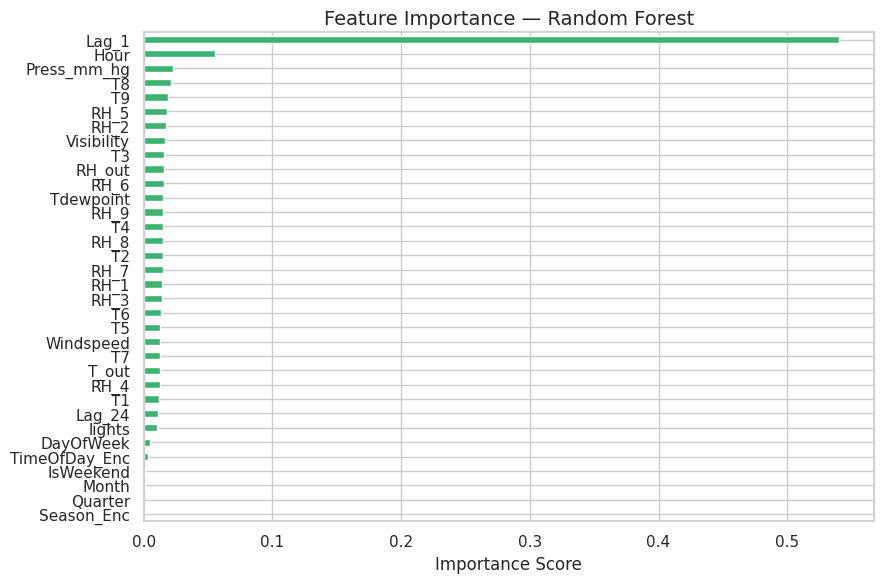

In [35]:
# ── Feature Importance (Random Forest) ───────────────────────────────────────
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=PRED_FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='mediumseagreen', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

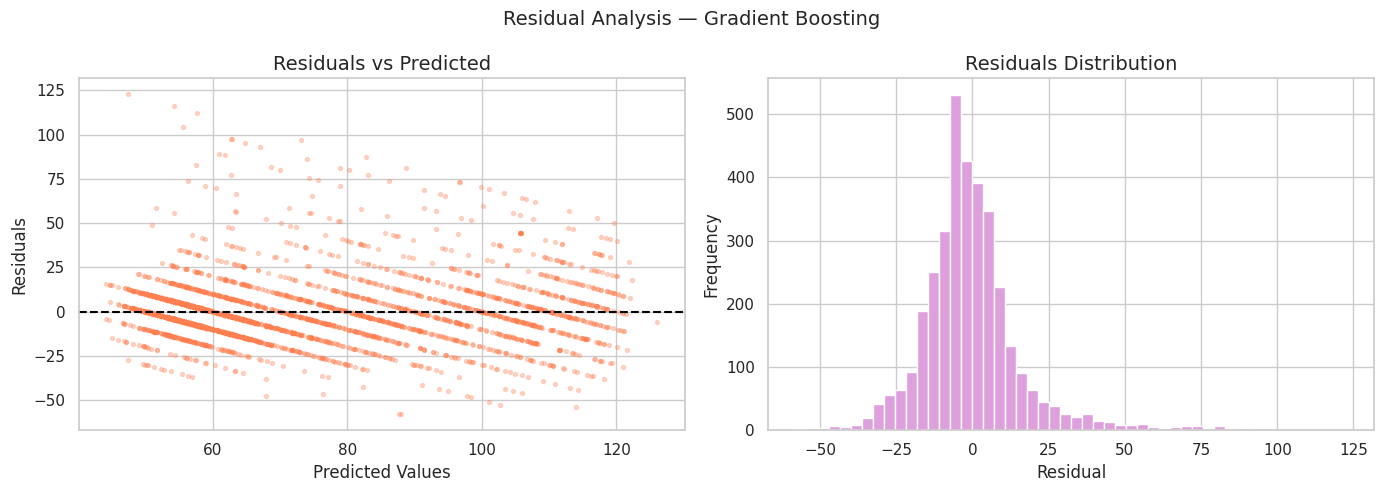

In [36]:
# ── Residuals Plot ────────────────────────────────────────────────────────────
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=8, color='coral')
axes[0].axhline(0, color='black', lw=1.5, linestyle='--')
axes[0].set_title('Residuals vs Predicted')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')

# Residuals Distribution
axes[1].hist(residuals, bins=50, color='plum', edgecolor='white')
axes[1].set_title('Residuals Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

plt.suptitle(f'Residual Analysis — {best_model_name}', fontsize=14)
plt.tight_layout()
plt.show()

---
## Section 12 — Cluster Interpretation

After fitting K-Means, each cluster represents a distinct **household energy-usage pattern**.
Interpret each cluster by examining:
- Mean energy consumption level (low / medium / high)
- Dominant time of day
- Dominant day type (weekday / weekend)
- Seasonal pattern

**Fill in the table below after running your analysis:**

| Cluster | Label | Avg Consumption | Peak Hour | Day Type | Season |
|---|---|---|---|---|---|
| 0 | *e.g. Low Off-Peak Users* | — | — | — | — |
| 1 | *e.g. Moderate Weekday Users* | — | — | — | — |
| 2 | *e.g. High Evening Users* | — | — | — | — |

> Fill in based on the cluster profile table from Section 9.

<Figure size 1000x500 with 0 Axes>

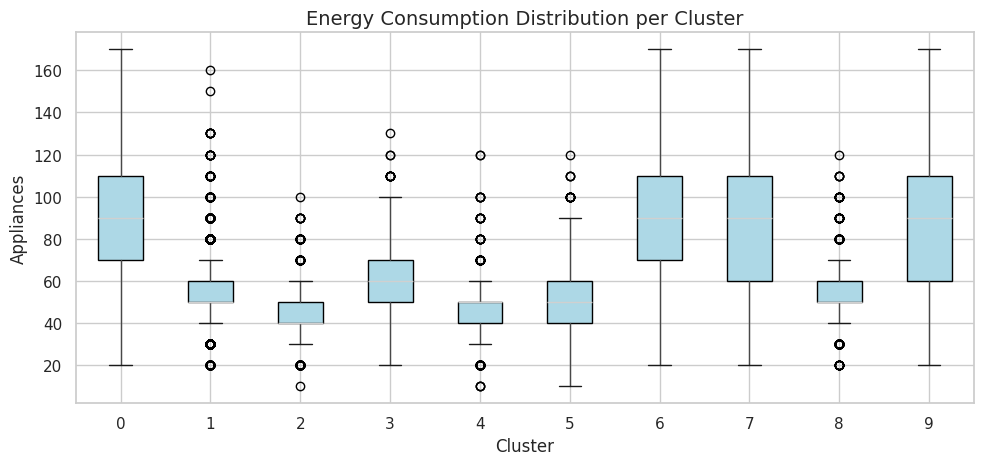

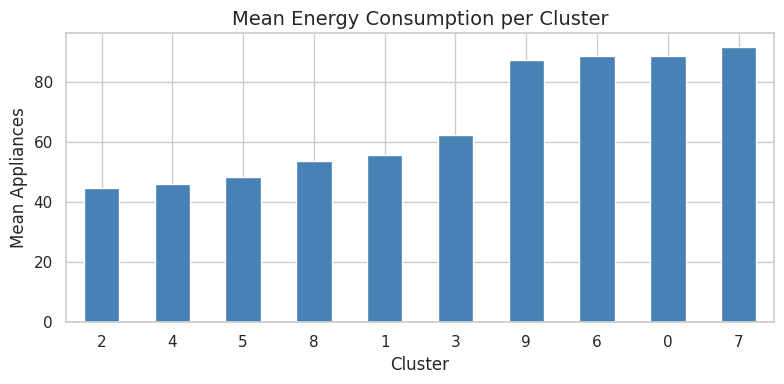

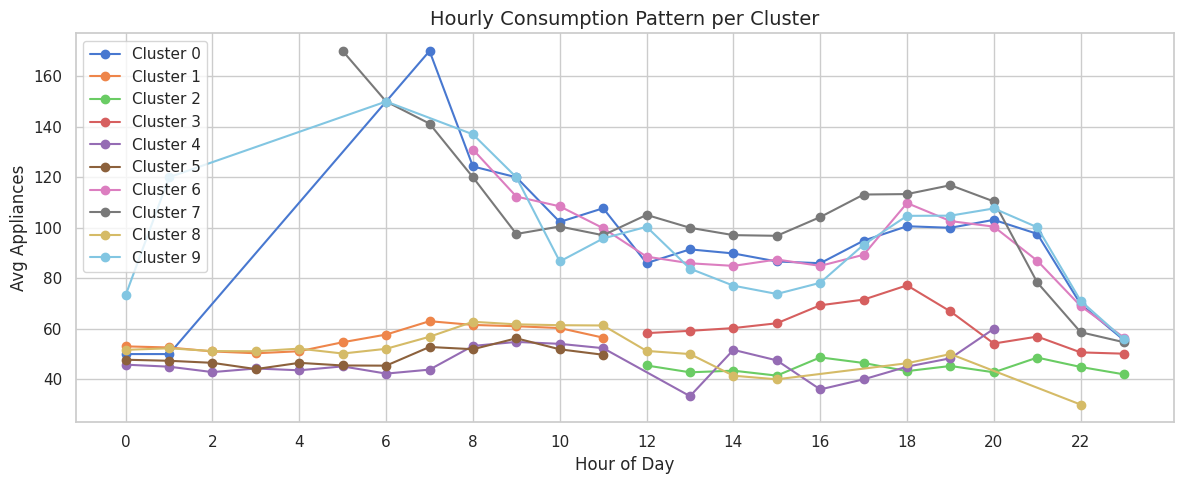

In [37]:
# ── Cluster Interpretation Plots ──────────────────────────────────────────────

# (a) Box plot of target per cluster
plt.figure(figsize=(10, 5))
df.boxplot(column=TARGET_COLUMN, by='Cluster', patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
plt.title(f'Energy Consumption Distribution per Cluster')
plt.suptitle('')
plt.xlabel('Cluster')
plt.ylabel(TARGET_COLUMN)
plt.tight_layout()
plt.show()

# (b) Mean consumption per cluster — bar chart
cluster_means = df.groupby('Cluster')[TARGET_COLUMN].mean().sort_values()
plt.figure(figsize=(8, 4))
cluster_means.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Mean Energy Consumption per Cluster')
plt.xlabel('Cluster')
plt.ylabel(f'Mean {TARGET_COLUMN}')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# (c) Hourly consumption by cluster
plt.figure(figsize=(12, 5))
for cluster_id in range(OPTIMAL_K):
    subset = df[df['Cluster'] == cluster_id]
    hourly = subset.groupby('Hour')[TARGET_COLUMN].mean()
    plt.plot(hourly.index, hourly.values, marker='o', label=f'Cluster {cluster_id}')

plt.title('Hourly Consumption Pattern per Cluster')
plt.xlabel('Hour of Day')
plt.ylabel(f'Avg {TARGET_COLUMN}')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.tight_layout()
plt.show()

---
## Section 13 — Energy-Related Insights and Recommendations

Based on the cluster profiles and prediction model, we derive practical recommendations.

> **Note:** The placeholder recommendations below should be revised after running your actual analysis.

### 🔍 Key Insights (Template — replace with your findings)

1. **Peak Consumption Hours** — Consumption is likely highest during [replace with your actual peak hours]. Households in this period belong predominantly to Cluster [X].

2. **Weekend vs Weekday** — [Describe any difference you observe in the data].

3. **Seasonal Variation** — [Describe which month or season has the highest consumption and why].

4. **High-Consumption Cluster** — Cluster [X] shows significantly higher average energy use. These households are prime targets for energy-efficiency interventions.

5. **Low-Consumption Cluster** — Cluster [Y] represents efficient energy users. Their patterns can serve as benchmarks for energy-saving programs.

### 💡 Recommendations

| # | Recommendation | Target Cluster |
|---|---|---|
| 1 | Shift high-power appliance usage (washing machines, dishwashers) to off-peak hours | High-consumption clusters |
| 2 | Introduce time-of-use tariffs to incentivize off-peak energy use | All clusters |
| 3 | Deploy smart meters and real-time dashboards for high-consumption households | High-consumption clusters |
| 4 | Offer energy audits to households in the high-usage cluster | High-consumption clusters |
| 5 | Promote seasonal energy-saving campaigns (insulation in winter, shading in summer) | All clusters |

=== Cluster Summary Statistics ===
            Mean  Median  Std Dev  Min  Max  Count
Cluster                                           
0        88.8488    90.0  28.9911   20  170    886
1        55.6305    50.0  14.9398   20  160   4108
2        44.7696    40.0  14.5307   10  100    738
3        62.3454    60.0  17.6782   20  130   1488
4        46.1829    50.0  13.3622   10  120    875
5        48.3432    50.0  14.2561   10  120   2191
6        88.5257    90.0  27.3010   20  170   1655
7        91.6567    90.0  31.4310   20  170   2686
8        53.8604    50.0  12.7200   20  120   1461
9        87.4680    90.0  31.5831   20  170   1485


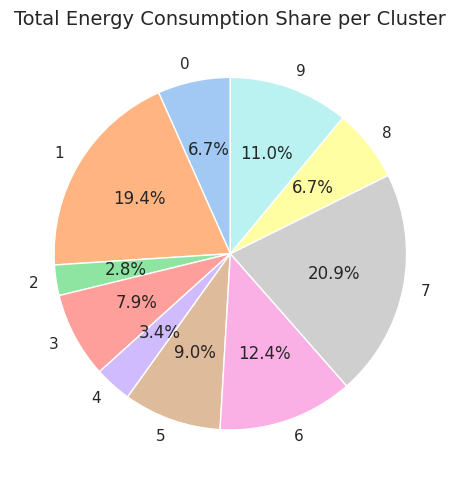

In [38]:
# ── Summary Statistics per Cluster ───────────────────────────────────────────
print('=== Cluster Summary Statistics ===')
summary = df.groupby('Cluster')[TARGET_COLUMN].agg(['mean','median','std','min','max','count'])
summary.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Count']
print(summary.round(4))

# ── Total Consumption per Cluster ─────────────────────────────────────────────
total_per_cluster = df.groupby('Cluster')[TARGET_COLUMN].sum()
fig, ax = plt.subplots(figsize=(7, 5))
total_per_cluster.plot(kind='pie', autopct='%1.1f%%', ax=ax,
                       colors=sns.color_palette('pastel', OPTIMAL_K),
                       startangle=90)
ax.set_ylabel('')
ax.set_title('Total Energy Consumption Share per Cluster')
plt.tight_layout()
plt.show()

---
## Section 14 — Conclusion

### Summary

This project applied a complete machine learning pipeline to household energy consumption data:

1. **Data Preparation** — The dataset was loaded, inspected, cleaned, and enriched with temporal and statistical features.
2. **Exploratory Analysis** — EDA revealed time-based patterns in energy usage, including hourly peaks, seasonal trends, and weekday vs. weekend differences.
3. **K-Means Clustering** — Households were segmented into `k` distinct energy-usage pattern groups. The optimal `k` was selected using the Elbow Method and Silhouette Score.
4. **PCA Visualization** — Clusters were visualized in 2D using PCA, confirming meaningful separation.
5. **Consumption Prediction** — A supervised regression model was trained to predict energy consumption. [Best model name] achieved the best performance with R² = [value].
6. **Recommendations** — Data-driven insights were generated for each cluster, targeting specific behavioural patterns for energy savings.

### Limitations

- The analysis is limited to the features available in the provided dataset.
- K-Means assumes spherical clusters; complex patterns may benefit from DBSCAN or Gaussian Mixture Models.
- Prediction accuracy depends heavily on data quality and available features.

### Future Work

- Incorporate external factors: weather data, household size, appliance inventory.
- Experiment with time-series forecasting models (LSTM, ARIMA) for temporal prediction.
- Build an interactive dashboard for real-time cluster assignment and consumption forecasting.
- Test hierarchical clustering or DBSCAN for potentially better pattern discovery.

---

> *Project completed as part of the IBM SkillsBuild Data Analytics with AI Internship.*